# Cell 1 — project path setup

import sys
from pathlib import Path

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [28]:
import sys
from pathlib import Path

project_root = Path(r"D:\Capstone_BBO")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Project root added:", project_root)

Project root added: D:\Capstone_BBO


In [29]:
# Cell 2 — imports

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from src.loaders import load_function
from src.utils import get_best_point, get_top_points, format_query

from sklearn.model_selection import ParameterGrid, ParameterSampler
from sklearn.metrics import mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [30]:
# Cell 3 — choose the week

week_num = 21
data_root = Path(rf"D:\Capstone_BBO\data\week_{week_num}")

print(rf"Working on Week {week_num}")
print("Data folder:", data_root.resolve())

Working on Week 21
Data folder: D:\Capstone_BBO\data\week_21


In [31]:
# Cell 4 — load all 8 functions automatically

functions_data = {}

for fn in range(1, 9):
    function_folder = data_root / f"function_{fn}"
    inputs_path = function_folder / "initial_inputs.npy"
    outputs_path = function_folder / "initial_outputs.npy"

    X, y = load_function(inputs_path, outputs_path)

    functions_data[fn] = {
        "folder": function_folder,
        "inputs_path": inputs_path,
        "outputs_path": outputs_path,
        "X": X,
        "y": y
    }

print("Loaded functions:", list(functions_data.keys()))

Loaded functions: [1, 2, 3, 4, 5, 6, 7, 8]


In [32]:
# Cell 5 — quick overview of all functions

overview_rows = []

for fn, data in functions_data.items():
    X = data["X"]
    y = data["y"]

    overview_rows.append({
        "function": fn,
        "n_points": X.shape[0],
        "dimension": X.shape[1],
        "y_min": float(np.min(y)),
        "y_max": float(np.max(y)),
        "y_mean": float(np.mean(y)),
        "y_std": float(np.std(y))
    })

overview_df = pd.DataFrame(overview_rows)
overview_df

,function,n_points,dimension,y_min,y_max,y_mean,y_std
0,1,19,2,-0.003606,0.000053,-0.000187,0.000806
1,2,19,2,-0.065624,0.702507,0.328784,0.271564
2,3,24,3,-0.398926,-0.015424,-0.093929,0.074035
3,4,39,4,-32.625660,-0.598733,-14.557313,9.100967
4,5,29,4,0.112940,6065.515500,1228.792316,1874.876982
5,6,29,5,-2.571170,-0.597593,-1.299865,0.514469
6,7,39,6,0.002701,1.783432,0.364763,0.472380
7,8,49,8,5.592193,9.598482,8.021344,1.039959


In [33]:
# Cell 6 — best point for each function

best_rows = []

for fn, data in functions_data.items():
    X = data["X"]
    y = data["y"]

    best_idx, best_x, best_y = get_best_point(X, y)

    best_rows.append({
        "function": fn,
        "best_index": int(best_idx),
        "best_output": float(best_y),
        "best_point": best_x,
        "formatted_best_point": format_query(best_x)
    })

best_df = pd.DataFrame(best_rows)
best_df

,function,best_index,best_output,best_point,formatted_best_point
0,1,15,0.000053,"[0.374545, 0.474256]",0.374545-0.474256
1,2,15,0.702507,"[0.691615, 0.662198]",0.691615-0.662198
2,3,21,-0.015424,"[0.38715, 0.34628, 0.507868]",0.387150-0.346280-0.507868
3,4,35,-0.598733,"[0.439522, 0.303303, 0.347783, 0.354975]",0.439522-0.303303-0.347783-0.354975
4,5,23,6065.515500,"[0.986591, 0.866088, 0.978811, 0.997373]",0.986591-0.866088-0.978811-0.997373
5,6,27,-0.597593,"[0.522774, 0.159809, 0.855098, 0.882709, 0.021...",0.522774-0.159809-0.855098-0.882709-0.021392
6,7,38,1.783432,"[0.055303, 0.33052, 0.13069, 0.225122, 0.34592...",0.055303-0.330520-0.130690-0.225122-0.345925-0...
7,8,40,9.598482,"[0.056447, 0.065956, 0.022929, 0.038786, 0.403...",0.056447-0.065956-0.022929-0.038786-0.403935-0...


In [34]:
# Cell 7 — top 5 points for a chosen function

# This lets you inspect one function in detail without changing paths.
inspect_function = 3

X = functions_data[inspect_function]["X"]
y = functions_data[inspect_function]["y"]

top_idx, top_X, top_y = get_top_points(X, y, top_n=5)

col_names = [f"x{i+1}" for i in range(X.shape[1])]
top_df = pd.DataFrame(top_X, columns=col_names)
top_df["y"] = top_y
top_df["original_index"] = top_idx

print(f"Top 5 points for Function {inspect_function}")
top_df

Top 5 points for Function 3


,x1,x2,x3,y,original_index
0,0.387150,0.346280,0.507868,-0.015424,21
1,0.492581,0.611593,0.340176,-0.034835,3
2,0.600097,0.725136,0.066089,-0.036378,13
3,0.338059,0.138073,0.464730,-0.036898,22
4,0.492581,0.590954,0.340176,-0.039700,16


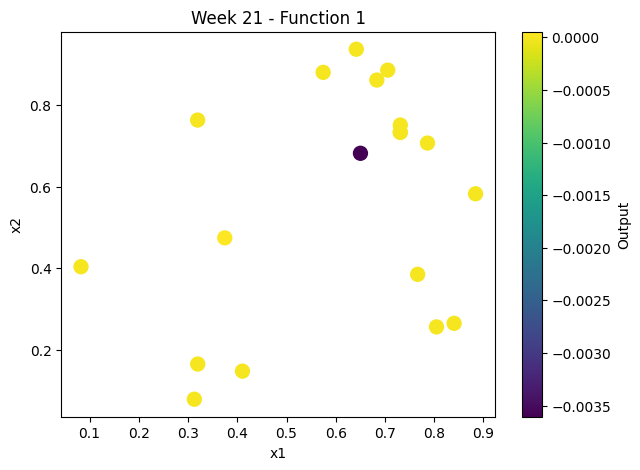

In [35]:
#Cell 9 — create initial candidate table

# This gives you a starting point for all 8 functions.

# For now, the initial candidate is just the current best point. Later we will improve this.

inspect_function = 1

X = functions_data[inspect_function]["X"]
y = functions_data[inspect_function]["y"]

if X.shape[1] == 2:
    plt.figure(figsize=(7,5))
    sc = plt.scatter(X[:, 0], X[:, 1], c=y, s=100)
    plt.colorbar(sc, label="Output")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(f"Week {week_num} - Function {inspect_function}")
    plt.show()
else:
    print(f"Function {inspect_function} is {X.shape[1]}D, so no simple 2D scatter plot.")

In [36]:
def train_nn_surrogate(X, y, epochs=200, batch_size=4, verbose=0):
    """
    Train a small neural-network surrogate model for regression.
    """
    X = np.array(X, dtype=float)
    y = np.array(y, dtype=float)

    model = keras.Sequential([
        layers.Input(shape=(X.shape[1],)),
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        loss="mse"
    )

    history = model.fit(
        X, y,
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose
    )

    return model, history


def generate_nn_candidate(X, y, n_random=3000, random_state=42):
    """
    Fit a small neural network surrogate and use it to rank random
    candidate points in [0,1]^d by predicted output.
    """
    rng = np.random.default_rng(random_state)
    dim = X.shape[1]

    nn_model, history = train_nn_surrogate(X, y, epochs=200, batch_size=4, verbose=0)

    X_search = rng.uniform(0, 1, size=(n_random, dim))
    preds = nn_model.predict(X_search, verbose=0).flatten()

    best_idx = np.argmax(preds)
    best_candidate = X_search[best_idx]

    return best_candidate, nn_model, history, X_search, preds

In [37]:
def tune_mlp_candidate(X, y, random_state=42, n_iter=8):
    """
    Small random search for MLP surrogate.
    Returns best candidate and tuning metadata.
    """
    X = np.array(X, dtype=float)
    y = np.array(y, dtype=float)

    param_dist = {
        "mlp__hidden_layer_sizes": [(16,), (32,), (32, 16), (64, 32)],
        "mlp__alpha": [0.0001, 0.001, 0.01],
        "mlp__learning_rate_init": [0.001, 0.005, 0.01],
        "mlp__max_iter": [1000, 2000],
    }

    sampled_params = list(ParameterSampler(param_dist, n_iter=n_iter, random_state=random_state))

    best_result = None
    rng = np.random.default_rng(random_state)

    for params in sampled_params:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("mlp", MLPRegressor(
                hidden_layer_sizes=params["mlp__hidden_layer_sizes"],
                alpha=params["mlp__alpha"],
                learning_rate_init=params["mlp__learning_rate_init"],
                max_iter=params["mlp__max_iter"],
                activation="relu",
                solver="adam",
                random_state=random_state
            ))
        ])

        model.fit(X, y)
        y_pred = model.predict(X)
        mse = mean_squared_error(y, y_pred)

        dim = X.shape[1]
        X_search = rng.uniform(0, 1, size=(3000, dim))
        preds = model.predict(X_search)

        best_idx = np.argmax(preds)
        candidate = X_search[best_idx]

        result = {
            "candidate": candidate,
            "model": model,
            "score_mse": mse,
            "hidden_layer_sizes": params["mlp__hidden_layer_sizes"],
            "alpha": params["mlp__alpha"],
            "learning_rate_init": params["mlp__learning_rate_init"],
            "max_iter": params["mlp__max_iter"],
            "pred_best": float(preds[best_idx]),
        }

        if best_result is None or result["score_mse"] < best_result["score_mse"]:
            best_result = result

    return best_result

In [38]:
manual_candidates = {
    1: None,
    2: None,
    3: None,
    4: None,
    5: None,
    6: None,
    7: None,
    8: None
}

In [39]:
def generate_gp_candidate(X, y, n_random=3000, beta=2.0, random_state=42):
    """
    Fit a Gaussian Process and choose a candidate using
    an Upper Confidence Bound (UCB) acquisition rule.

    score = mean + beta * std
    """
    rng = np.random.default_rng(random_state)
    dim = X.shape[1]

    # Candidate search points sampled in [0, 1]^dim
    X_search = rng.uniform(0, 1, size=(n_random, dim))

    # GP model
    kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=np.ones(dim), length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))

    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=1e-8,
        normalize_y=True,
        n_restarts_optimizer=5,
        random_state=random_state
    )

    gp.fit(X, y)
    mu, std = gp.predict(X_search, return_std=True)

    ucb = mu + beta * std
    order = np.argsort(ucb)[::-1]

    for idx in order:
        candidate = X_search[idx]
        already_exists = np.any(np.all(np.isclose(X, candidate, atol=1e-6), axis=1))
        if not already_exists:
            return candidate, gp, X_search, mu, std, ucb

    return X_search[order[0]], gp, X_search, mu, std, ucb

In [40]:
def tune_gp_candidate(X, y, random_state=42):
    """
    Small GP tuning over beta and kernel assumptions.
    Returns best candidate and tuning metadata.
    """
    X = np.array(X, dtype=float)
    y = np.array(y, dtype=float)

    param_grid = [
        {"beta": 1.0, "length_scale": 0.2, "noise": 1e-6},
        {"beta": 2.0, "length_scale": 0.2, "noise": 1e-6},
        {"beta": 3.0, "length_scale": 0.2, "noise": 1e-6},
        {"beta": 1.0, "length_scale": 0.5, "noise": 1e-5},
        {"beta": 2.0, "length_scale": 0.5, "noise": 1e-5},
        {"beta": 3.0, "length_scale": 0.5, "noise": 1e-5},
        {"beta": 2.0, "length_scale": 1.0, "noise": 1e-4},
    ]

    best_result = None
    rng = np.random.default_rng(random_state)

    for params in param_grid:
        kernel = (
            C(1.0, (1e-3, 1e3))
            * RBF(length_scale=params["length_scale"], length_scale_bounds=(1e-2, 1e2))
            + WhiteKernel(noise_level=params["noise"], noise_level_bounds=(1e-8, 1e-1))
        )

        gp = GaussianProcessRegressor(
            kernel=kernel,
            normalize_y=True,
            random_state=random_state,
            n_restarts_optimizer=3
        )

        gp.fit(X, y)
        y_pred = gp.predict(X)
        mse = mean_squared_error(y, y_pred)

        dim = X.shape[1]
        X_search = rng.uniform(0, 1, size=(3000, dim))
        mu, std = gp.predict(X_search, return_std=True)
        ucb = mu + params["beta"] * std

        best_idx = np.argmax(ucb)
        candidate = X_search[best_idx]

        result = {
            "candidate": candidate,
            "model": gp,
            "score_mse": mse,
            "beta": params["beta"],
            "length_scale": params["length_scale"],
            "noise": params["noise"],
            "mu_best": float(mu[best_idx]),
            "std_best": float(std[best_idx]),
            "ucb_best": float(ucb[best_idx]),
        }

        if best_result is None or result["score_mse"] < best_result["score_mse"]:
            best_result = result

    return best_result

In [41]:
np.random.seed(42)

auto_candidates = {}
candidate_method = {}
tuning_metadata = {}

for fn, data in functions_data.items():
    X = data["X"]
    y = data["y"]
    dim = X.shape[1]

    if dim <= 4:
        result = tune_gp_candidate(X, y, random_state=42 + fn)
        auto_candidates[fn] = result["candidate"]
        candidate_method[fn] = "GP_UCB_tuned"
        tuning_metadata[fn] = result

    else:
        result = tune_mlp_candidate(X, y, random_state=100 + fn, n_iter=8)
        auto_candidates[fn] = result["candidate"]
        candidate_method[fn] = "MLP_surrogate_tuned"
        tuning_metadata[fn] = result

auto_candidates

d:\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The opt

{1: array([0.30428965, 0.43189474]),
 2: array([0.67151289, 0.64280956]),
 3: array([0.75027393, 0.80449185, 0.00234218]),
 4: array([0.36611541, 0.4349516 , 0.3948324 , 0.41963574]),
 5: array([0.98970361, 0.86791873, 0.96610763, 0.8260224 ]),
 6: array([0.52277372, 0.15980879, 0.85509765, 0.88270887, 0.02139161]),
 7: array([0.05530343, 0.33051989, 0.13069031, 0.2251219 , 0.34592463,
        0.80630703]),
 8: array([0.2194278 , 0.0061116 , 0.85239226, 0.71083477, 0.98138441,
        0.99468108, 0.01900884, 0.46499932])}

In [42]:
tuning_rows = []

for fn, meta in tuning_metadata.items():
    row = {
        "function": fn,
        "method": candidate_method[fn],
        "score_mse": meta["score_mse"],
    }

    if candidate_method[fn] == "GP_UCB_tuned":
        row.update({
            "beta": meta["beta"],
            "length_scale": meta["length_scale"],
            "noise": meta["noise"],
            "pred_signal": meta["ucb_best"],
        })
    else:
        row.update({
            "hidden_layer_sizes": str(meta["hidden_layer_sizes"]),
            "alpha": meta["alpha"],
            "learning_rate_init": meta["learning_rate_init"],
            "max_iter": meta["max_iter"],
            "pred_signal": meta["pred_best"],
        })

    tuning_rows.append(row)

tuning_df = pd.DataFrame(tuning_rows)
tuning_df

,function,method,score_mse,beta,length_scale,noise,pred_signal,hidden_layer_sizes,alpha,learning_rate_init,max_iter
0,1,GP_UCB_tuned,1.045111e-18,1.0,0.2,0.000001,0.000695,NaN,NaN,NaN,NaN
1,2,GP_UCB_tuned,7.292142e-05,1.0,0.2,0.000001,0.768696,NaN,NaN,NaN,NaN
2,3,GP_UCB_tuned,2.035504e-06,1.0,0.2,0.000001,0.019400,NaN,NaN,NaN,NaN
3,4,GP_UCB_tuned,4.949118e-11,1.0,0.5,0.000010,-0.318771,NaN,NaN,NaN,NaN
4,5,GP_UCB_tuned,9.338684e-08,1.0,0.5,0.000010,5015.919459,NaN,NaN,NaN,NaN
5,6,MLP_surrogate_tuned,3.282015e-03,NaN,NaN,NaN,-0.650729,"(32, 16)",0.001,0.01,2000.0
6,7,MLP_surrogate_tuned,2.239612e-04,NaN,NaN,NaN,1.831742,"(64, 32)",0.001,0.01,2000.0
7,8,MLP_surrogate_tuned,1.403820e-02,NaN,NaN,NaN,12.695571,"(32,)",0.001,0.01,2000.0


In [43]:
quality_rows = []

for fn, data in functions_data.items():
    X = data["X"]
    y = data["y"]

    best_idx, best_x, best_y = get_best_point(X, y)
    chosen_candidate = auto_candidates[fn]

    distance_to_best = np.linalg.norm(chosen_candidate - best_x)

    row = {
        "function": fn,
        "dimension": X.shape[1],
        "method": candidate_method[fn],
        "best_output_so_far": float(best_y),
        "distance_to_best_point": float(distance_to_best)
    }

    if candidate_method[fn] == "GP_UCB_tuned":
        row.update({
            "predicted_signal": tuning_metadata[fn]["ucb_best"],
            "model_fit_proxy": tuning_metadata[fn]["score_mse"]
        })
    else:
        row.update({
            "predicted_signal": tuning_metadata[fn]["pred_best"],
            "model_fit_proxy": tuning_metadata[fn]["score_mse"]
        })

    quality_rows.append(row)

quality_df = pd.DataFrame(quality_rows)
quality_df

,function,dimension,method,best_output_so_far,distance_to_best_point,predicted_signal,model_fit_proxy
0,1,2,GP_UCB_tuned,0.000053,8.203834e-02,0.000695,1.045111e-18
1,2,2,GP_UCB_tuned,0.702507,2.792860e-02,0.768696,7.292142e-05
2,3,3,GP_UCB_tuned,-0.015424,7.728994e-01,0.019400,2.035504e-06
3,4,4,GP_UCB_tuned,-0.598733,1.706298e-01,-0.318771,4.949118e-11
4,5,4,GP_UCB_tuned,6065.515500,1.718588e-01,5015.919459,9.338684e-08
5,6,5,MLP_surrogate_tuned,-0.597593,6.444020e-07,-0.650729,3.282015e-03
6,7,6,MLP_surrogate_tuned,1.783432,6.608096e-07,1.831742,2.239612e-04
7,8,8,MLP_surrogate_tuned,9.598482,1.394360e+00,12.695571,1.403820e-02


In [44]:
inspect_nn_function = 5

if inspect_nn_function in tuning_metadata:
    meta = tuning_metadata[inspect_nn_function]

    print("Function:", inspect_nn_function)
    print("Method:", candidate_method[inspect_nn_function])
    print("Chosen hyperparameters:")

    if candidate_method[inspect_nn_function] == "MLP_surrogate_tuned":
        print("hidden_layer_sizes:", meta["hidden_layer_sizes"])
        print("alpha:", meta["alpha"])
        print("learning_rate_init:", meta["learning_rate_init"])
        print("max_iter:", meta["max_iter"])
        print("training_mse:", meta["score_mse"])
        print("best_predicted_signal:", meta["pred_best"])
    else:
        print("This function is not using the MLP surrogate.")
else:
    print("No tuning metadata found for this function.")

Function: 5
Method: GP_UCB_tuned
Chosen hyperparameters:
This function is not using the MLP surrogate.


In [45]:
inspect_nn_function = 5

if inspect_nn_function in auto_candidates:
    print("Method:", candidate_method[inspect_nn_function])
    print("Suggested candidate:", auto_candidates[inspect_nn_function])
    print("Formatted query:", format_query(auto_candidates[inspect_nn_function]))
else:
    print("No candidate found.")

Method: GP_UCB_tuned
Suggested candidate: [0.98970361 0.86791873 0.96610763 0.8260224 ]
Formatted query: 0.989704-0.867919-0.966108-0.826022


In [46]:
submission_rows = []

for fn, data in functions_data.items():
    X = data["X"]
    y = data["y"]

    best_idx, best_x, best_y = get_best_point(X, y)

    chosen_candidate = manual_candidates.get(fn)
    if chosen_candidate is None:
        chosen_candidate = auto_candidates[fn]

    chosen_candidate = np.array(chosen_candidate, dtype=float)
    chosen_candidate = np.clip(chosen_candidate, 0, 1)

    already_exists = np.any(np.all(np.isclose(X, chosen_candidate, atol=1e-12), axis=1))

    submission_rows.append({
        "function": fn,
        "dimension": X.shape[1],
        "method": candidate_method[fn],
        "best_output_so_far": float(best_y),
        "best_point_so_far": format_query(best_x),
        "chosen_candidate_array": chosen_candidate,
        "query": format_query(chosen_candidate),
        "already_exists": bool(already_exists)
    })

submission_df = pd.DataFrame(submission_rows)
submission_df

,function,dimension,method,best_output_so_far,best_point_so_far,chosen_candidate_array,query,already_exists
0,1,2,GP_UCB_tuned,0.000053,0.374545-0.474256,"[0.3042896547466002, 0.43189474394541383]",0.304290-0.431895,False
1,2,2,GP_UCB_tuned,0.702507,0.691615-0.662198,"[0.6715128872718119, 0.6428095560325241]",0.671513-0.642810,False
2,3,3,GP_UCB_tuned,-0.015424,0.387150-0.346280-0.507868,"[0.7502739278164573, 0.8044918497709403, 0.002...",0.750274-0.804492-0.002342,False
3,4,4,GP_UCB_tuned,-0.598733,0.439522-0.303303-0.347783-0.354975,"[0.3661154104103108, 0.4349515975802276, 0.394...",0.366115-0.434952-0.394832-0.419636,False
4,5,4,GP_UCB_tuned,6065.515500,0.986591-0.866088-0.978811-0.997373,"[0.9897036117266039, 0.8679187310628029, 0.966...",0.989704-0.867919-0.966108-0.826022,False
5,6,5,MLP_surrogate_tuned,-0.597593,0.522774-0.159809-0.855098-0.882709-0.021392,"[0.5227737246258399, 0.15980878683126576, 0.85...",0.522774-0.159809-0.855098-0.882709-0.021392,False
6,7,6,MLP_surrogate_tuned,1.783432,0.055303-0.330520-0.130690-0.225122-0.345925-0...,"[0.055303428154576784, 0.3305198883942747, 0.1...",0.055303-0.330520-0.130690-0.225122-0.345925-0...,True
7,8,8,MLP_surrogate_tuned,9.598482,0.056447-0.065956-0.022929-0.038786-0.403935-0...,"[0.21942779647996202, 0.006111601660840904, 0....",0.219428-0.006112-0.852392-0.710835-0.981384-0...,False


In [47]:
repeated_df = submission_df[submission_df["already_exists"] == True]
repeated_df

,function,dimension,method,best_output_so_far,best_point_so_far,chosen_candidate_array,query,already_exists
6,7,6,MLP_surrogate_tuned,1.783432,0.055303-0.330520-0.130690-0.225122-0.345925-0...,"[0.055303428154576784, 0.3305198883942747, 0.1...",0.055303-0.330520-0.130690-0.225122-0.345925-0...,True


In [48]:
strategy_rows = []

for fn, row in submission_df.iterrows():
    method = row["method"]
    dim = row["dimension"]

    if method == "GP_UCB_tuned":
        strategy_type = "structured_model_based_search"
    elif method == "MLP_surrogate_tuned":
        strategy_type = "flexible_model_based_search"
    else:
        strategy_type = "manual_override"

    strategy_rows.append({
        "function": row["function"],
        "dimension": dim,
        "method": method,
        "strategy_type": strategy_type,
        "query": row["query"],
        "already_exists": row["already_exists"]
    })

strategy_df = pd.DataFrame(strategy_rows)
strategy_df

,function,dimension,method,strategy_type,query,already_exists
0,1,2,GP_UCB_tuned,structured_model_based_search,0.304290-0.431895,False
1,2,2,GP_UCB_tuned,structured_model_based_search,0.671513-0.642810,False
2,3,3,GP_UCB_tuned,structured_model_based_search,0.750274-0.804492-0.002342,False
3,4,4,GP_UCB_tuned,structured_model_based_search,0.366115-0.434952-0.394832-0.419636,False
4,5,4,GP_UCB_tuned,structured_model_based_search,0.989704-0.867919-0.966108-0.826022,False
5,6,5,MLP_surrogate_tuned,flexible_model_based_search,0.522774-0.159809-0.855098-0.882709-0.021392,False
6,7,6,MLP_surrogate_tuned,flexible_model_based_search,0.055303-0.330520-0.130690-0.225122-0.345925-0...,True
7,8,8,MLP_surrogate_tuned,flexible_model_based_search,0.219428-0.006112-0.852392-0.710835-0.981384-0...,False


In [49]:
submission_export = submission_df[["function", "query"]].copy()

output_file = Path(rf"D:\Capstone_BBO\submissiones\week_{week_num}_submission.csv")
submission_export.to_csv(output_file, index=False)

print("Saved submission file to:", output_file.resolve())
submission_export

Saved submission file to: D:\Capstone_BBO\submissiones\week_21_submission.csv


,function,query
0,1,0.304290-0.431895
1,2,0.671513-0.642810
2,3,0.750274-0.804492-0.002342
3,4,0.366115-0.434952-0.394832-0.419636
4,5,0.989704-0.867919-0.966108-0.826022
5,6,0.522774-0.159809-0.855098-0.882709-0.021392
6,7,0.055303-0.330520-0.130690-0.225122-0.345925-0...
7,8,0.219428-0.006112-0.852392-0.710835-0.981384-0...


In [50]:
tuning_output_file = Path(f"../submissions/week_{week_num}_tuning_summary.csv")
tuning_output_file.parent.mkdir(parents=True, exist_ok=True)

tuning_df.to_csv(tuning_output_file, index=False)

print("Saved tuning summary to:", tuning_output_file.resolve())

Saved tuning summary to: D:\Capstone_BBO\submissions\week_21_tuning_summary.csv
